# Tutorial n°4

## Temperature evolution of the electronic spectra

### A. The cationic Methylene-Pyrene Isomers

In [ ]:
import deMonPy
deMonPy.configure_from_file("../global.json")

In [3]:
from deMonPy.molden import read_XYZ

images,comm = read_XYZ("./data/methylpyren_1.xyz")
mpyren_1 = images[-1]

 ✅ Loaded 1 elements from XYZ file.


In [4]:
from deMonPy.deMonNano import deMonNano

WORKDIR = ".run/tutorial-4/A/"

parameters_opt = {
        "DEMON_EXECUTABLE":EXECUTABLE,
        "BASIS":{
            "PTYPE":"BIO",
            "SKFILE":BASIS
        },
        "DEMON_PARAMETERS":{
            "ACTIVE":{
                "DFTB":{
                    "SCC":True
                },
                "CHARGE":1.0
            },
        },
        "DEMON_MODULE":{
            "ACTIVE":{
                "OPT":{
                    "MAX":9999,
                    "OUT":1,
                    "TRAJECTORY":True
                }
            }
        }
    }

dem = deMonNano(
        title="CALCULATION DEMONANO",
        workdir=WORKDIR,
        **parameters_opt
    )

dem.calculate(
        symbols=mpyren_1.symbols,
        positions=mpyren_1.positions
    )

 ✅ Loaded 150 elements from XYZ file.


In [5]:
from ase.visualize import view

#view(dem.results["trajectory"])

### B. The TD-DFTB

In [6]:
optimized_geometry_1 = dem.results["output_geometry"]
print("Optimized geometry : ",optimized_geometry_1)

Optimized geometry :  Atoms(symbols='C17H11', pbc=False, initial_charges=...)


In [7]:
from deMonPy.deMonNano import deMonNano

WORKDIR = ".run/tutorial-4/B/"

parameters_lresp = {
        "DEMON_EXECUTABLE":EXECUTABLE,
        "BASIS":{
            "PTYPE":"BIO",
            "SKFILE":BASIS
        },
        "DEMON_PARAMETERS":{
            "ACTIVE":{
                "DFTB":{
                    "SCC":True
                },
                "CHARGE":1.0,
                "TD-DFTB":True
            },
        }
    }

dem = deMonNano(
        title="CALCULATION DEMONANO",
        workdir=WORKDIR,
        **parameters_lresp
    )

dem.calculate(
        symbols=optimized_geometry_1.symbols,
        positions=optimized_geometry_1.positions
    )

True


 ✅ Loaded 2 elements from XYZ file.


In [8]:
results = dem.results

iso1_singlet = results['singlet']
iso1_triplet = results['triplet']

### C. Comparizon with isomer 2

In [9]:
from deMonPy.molden import read_XYZ

images,comm = read_XYZ("./data/methylpyren_2.xyz")
mpyren_2 = images[-1]

 ✅ Loaded 1 elements from XYZ file.


In [10]:
from deMonPy.deMonNano import deMonNano

WORKDIR = ".run/tutorial-4/C/"

dem = deMonNano(
        title="CALCULATION DEMONANO",
        workdir=WORKDIR,
        **parameters_opt
    )

dem.calculate(
        symbols=mpyren_2.symbols,
        positions=mpyren_2.positions
    )

optimized_geometry_2 = dem.results["output_geometry"]

 ✅ Loaded 123 elements from XYZ file.


In [11]:
dem = deMonNano(
        title="CALCULATION DEMONANO",
        workdir=WORKDIR,
        **parameters_lresp
    )

dem.calculate(
        symbols=optimized_geometry_2.symbols,
        positions=optimized_geometry_2.positions
    )

results = dem.results

iso2_singlet = results['singlet']
iso2_triplet = results['triplet']

True
 ✅ Loaded 2 elements from XYZ file.


In [12]:
import numpy as np

def transform_to_table(data):
    table = []

    for elm in ["w","oscillator","weight","energy"]:
        table.append(
            [d[elm] for k,d in data.items()]
        )
    return np.array(table).T

tab1 = transform_to_table(iso1_singlet)
tab2 = transform_to_table(iso2_singlet)

print("Singlet table in isomer 1 : \n",tab1)
print("Singlet table in isomer 2 : \n",tab2)

Singlet table in isomer 1 : 
 [[2.079     0.0430939 0.537     2.01     ]
 [2.407     0.160279  0.312     1.572    ]
 [2.672     0.1373652 0.504     2.299    ]
 [2.843     0.        1.        2.843    ]
 [2.98      0.        1.        2.98     ]
 [3.109     0.0152016 0.764     2.866    ]
 [3.54      0.        1.        3.54     ]
 [3.591     0.02371   0.716     3.371    ]
 [3.831     0.        1.        3.831    ]
 [4.061     0.0464621 0.53      3.952    ]]
Singlet table in isomer 2 : 
 [[2.606000e+00 1.208855e-01 6.450000e-01 2.077000e+00]
 [2.750000e+00 1.144100e-03 5.800000e-01 2.624000e+00]
 [2.907000e+00 7.582900e-03 3.900000e-01 2.715000e+00]
 [3.417000e+00 1.171359e-01 5.320000e-01 2.958000e+00]
 [3.489000e+00 0.000000e+00 1.000000e+00 3.489000e+00]
 [3.640000e+00 2.298040e-02 8.110000e-01 3.505000e+00]
 [3.660000e+00 0.000000e+00 1.000000e+00 3.660000e+00]
 [3.788000e+00 2.031986e-01 3.530000e-01 3.262000e+00]
 [3.967000e+00 2.410134e-01 4.880000e-01 3.628000e+00]
 [4.036000e+00

### D. Temperature evolution 

In [19]:
print(optimized_geometry_1)

parameters_mdlresp = {
        "DEMON_EXECUTABLE":EXECUTABLE,
        "BASIS":{
            "PTYPE":"BIO",
            "SKFILE":BASIS
        },
        "DEMON_PARAMETERS":{
            "ACTIVE":{
                "DFTB":{
                    "SCC":True
                },
                "CHARGE":1,
                "TD-DFTB":{
                    "FRESP":10
                }
            },
        },
        "DEMON_MODULE":{
            "ACTIVE":{
                "MD":{
                    "MDYNAMICS":{
                        "RANDOM":300,
                    },
                    "TIMESTEP":0.5,
                    "MDSTEP":{
                        "MAX":100,
                        "OUT":1
                    },
                    "TRAJECTORY":True
                }
            }
        }
    }

Atoms(symbols='C17H11', pbc=False, initial_charges=...)


In [20]:
from deMonPy.deMonNano import deMonNano

WORKDIR = ".run/tutorial-4/D/"

dem = deMonNano(
        title="CALCULATION DEMONANO",
        workdir=WORKDIR,
        **parameters_mdlresp
    )

dem.calculate(
        symbols=optimized_geometry_1.symbols,
        positions=optimized_geometry_1.positions
    )

results = dem.results

{'FRESP': 10}
 ✅ Loaded 101 elements from XYZ file.


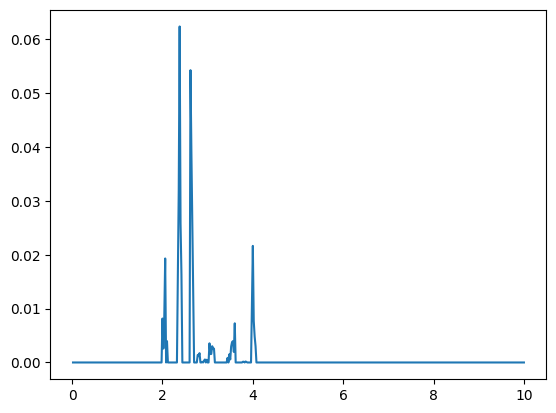

In [22]:
import os
import matplotlib.pyplot as plt

src = os.path.join(WORKDIR,"spectrum_final.out")

with open(src,"r") as fd:
    lines = fd.readlines()

data = np.array([[float(l.split()[0]),float(l.split()[1])] for l in lines])

plt.plot(data[:,0],data[:,1])
plt.show()